<a href="https://colab.research.google.com/github/pronabpaul/medimg-wavelet-spectral-analysis/blob/main/WaveletPacket_Fractal_Analysis_MedMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spectral, Wavelet Packet, and Fractal Characterisation of MedMNIST Datasets (OrganSMNIST and PathMNIST)

This work extends the previous study on spectral and texture analysis of MedMNIST datasets:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pronabpaul/medimg-spectral-analysis/blob/main/spectral_analysis.ipynb)

[![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.20260549.svg)](https://doi.org/10.5281/zenodo.20260549)



## Overview

This work investigates frequency-domain, texture-based, multiscale wavelet, and complexity descriptors for MedMNIST datasets, with a focus on **wavelet packet decomposition and enhanced multiscale characterisation**.

While the previous study concentrated on classical spectral and texture descriptors (FFT-based analysis and GLCM statistics), the current version extends the framework by adding:

- Wavelet packet decomposition for multiscale frequency-spatial analysis  
- Subband-level **relative energy and Shannon entropy** modelling  
- Box-counting fractal dimension for structural complexity estimation  
- Strengthened statistical validation and comparative feature evaluation  


## Datasets

This study uses two standard MedMNIST benchmarks:

- **OrganSMNIST** - abdominal CT-derived organ classification images  
- **PathMNIST** - histopathology image patches  

All experiments are performed on the official **28x28 resolution representations**.



## Major Contributions of This Work

The key contribution is the introduction of **wavelet packet-based feature analysis**, which enables a richer multiscale characterisation of medical images.

This allows:

- Multiscale decomposition beyond global Fourier representations  
- Localisation of discriminative structures across frequency subbands  
- Joint modelling of subband energy distribution and information entropy  
- Improved separation of imaging modalities compared to classical spectral features  

This work also uses **box-counting fractal dimension** as a coarse geometric complexity descriptor to capture structural differences between modalities. Sensitivity analysis across multiple wavelet families (`db2`, `db4`, `sym4`) confirms the robustness of the findings.


## Objective

The goal of this study is to assess whether **multiscale and complexity-aware descriptors** provide additional discriminatory power over classical spectral features when distinguishing medical imaging modalities in the MedMNIST benchmark.

In [2]:
import os
import sys
import numpy as np

# ---------------------------------------------------------------------
# Environment setup
# ---------------------------------------------------------------------
if np.__version__.startswith('2.'):
    print(f"Incompatible NumPy version detected: {np.__version__}")
    print("Downgrading to NumPy 1.26.4 and related packages...")
    !pip uninstall -y numpy pandas scipy scikit-learn 2>/dev/null
    !pip install --no-deps numpy==1.26.4 2>/dev/null
    !pip install pandas==2.2.2 scipy==1.13.1 scikit-learn==1.5.2 statsmodels==0.14.2 2>/dev/null
    print("Core packages pinned. Restarting kernel...")
    os._exit(0)
else:
    print(f"NumPy version: {np.__version__}")
    # Install core packages silently, suppressing harmless dependency conflicts
    !pip install -q pandas==2.2.2 scipy==1.13.1 scikit-learn==1.5.2 statsmodels==0.14.2 2>/dev/null

# ---------------------------------------------------------------------
# Install additional packages
# ---------------------------------------------------------------------
!pip install --no-deps -q medmnist PyWavelets 2>/dev/null

# ---------------------------------------------------------------------
# Print version information
# ---------------------------------------------------------------------
import medmnist
import pywt
import pandas as pd
import scipy
import sklearn

print(f"Pandas version: {pd.__version__}")
print(f"SciPy version: {scipy.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"MedMNIST version: {medmnist.__version__}")
print(f"PyWavelets version: {pywt.__version__}")
print("All required packages installed successfully.")

NumPy version: 1.26.4
Pandas version: 2.2.2
SciPy version: 1.13.1
scikit-learn version: 1.5.2
MedMNIST version: 3.0.2
PyWavelets version: 1.8.0
All required packages installed successfully.


In [3]:
# ---------------------------------------------------------------------
# Scientific computing
# ---------------------------------------------------------------------
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------
# Statistics
# ---------------------------------------------------------------------
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ---------------------------------------------------------------------
# Wavelet analysis
# ---------------------------------------------------------------------
import pywt

# ---------------------------------------------------------------------
# Dataset
# ---------------------------------------------------------------------
from medmnist import OrganSMNIST, PathMNIST

# ---------------------------------------------------------------------
# Image processing
# ---------------------------------------------------------------------
from skimage.filters import threshold_otsu

# ---------------------------------------------------------------------
# Machine learning
# ---------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------------
from tqdm import tqdm
import warnings

# ---------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------
np.random.seed(42)

# ---------------------------------------------------------------------
# Suppress non-critical warnings
# ---------------------------------------------------------------------
warnings.filterwarnings("ignore", category=FutureWarning)

print("Libraries imported successfully.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Random seed set to 42.")

Libraries imported successfully.
NumPy version: 1.26.4
Pandas version: 2.2.2
Random seed set to 42.


Data loader defined. Will use 5 random seeds: [42, 123, 456, 789, 1011]


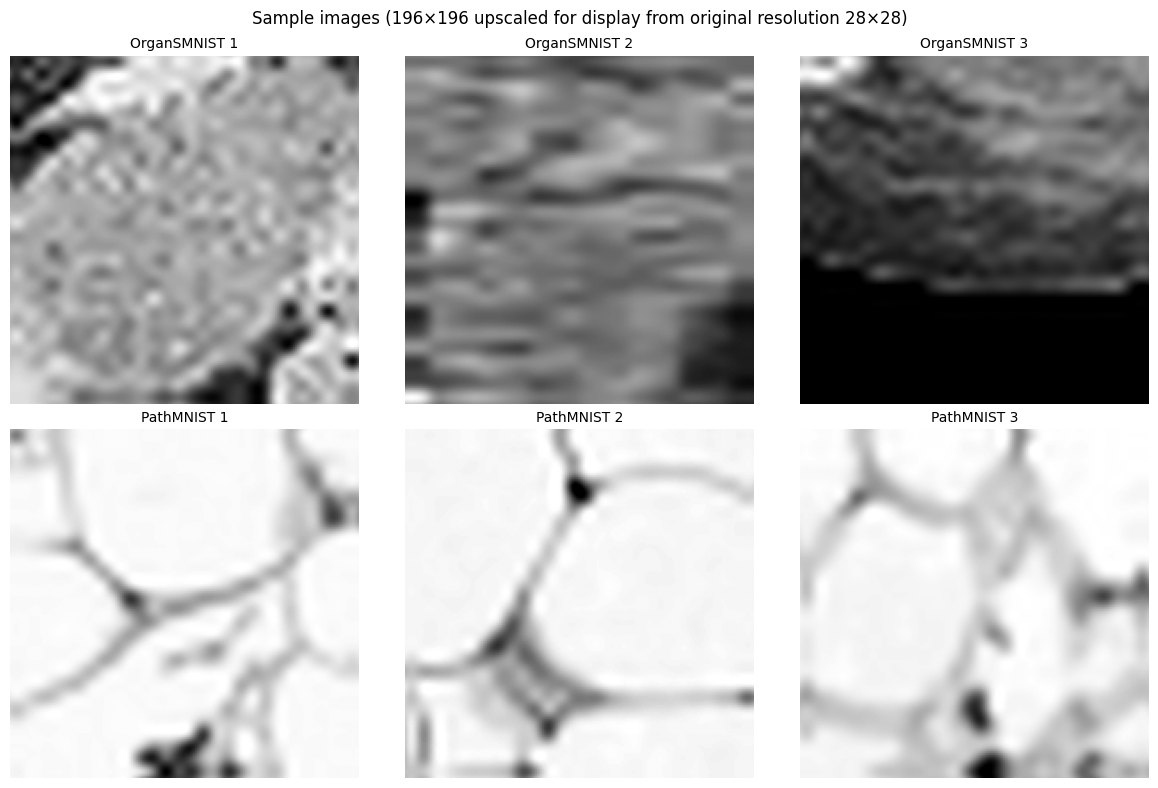

In [7]:
# ---------------------------------------------------------------------
# Data loading and stratified sampling
# ---------------------------------------------------------------------
def load_subsampled_data(seed, n_samples=500):
    """
    Load class-stratified subsets of OrganSMNIST and PathMNIST for analysis.

    PathMNIST images are converted from RGB to grayscale to ensure a
    consistent representation across datasets for spectral, wavelet,
    and fractal feature extraction.
    """
    rng = np.random.default_rng(seed)

    # Load datasets
    organ_full = OrganSMNIST(split='train', download=True)
    path_full = PathMNIST(split='train', download=True)

    # Safe label extraction
    def get_scalar_labels(dataset):
        labels = []
        for i in range(len(dataset)):
            lbl = dataset[i][1]
            lbl = lbl.item() if hasattr(lbl, "item") else int(lbl)
            labels.append(lbl)
        return labels

    organ_labels = get_scalar_labels(organ_full)
    path_labels = get_scalar_labels(path_full)

    # Exact stratified sampling
    def stratified_sample(dataset, labels, n, rng):
        unique = np.unique(labels)
        n_classes = len(unique)
        base = n // n_classes
        remainder = n % n_classes

        selected = []
        for i, lbl in enumerate(unique):
            n_take = base + (1 if i < remainder else 0)
            idx = [j for j, l in enumerate(labels) if l == lbl]
            if len(idx) < n_take:
                # Fallback if class has too few samples
                n_take = len(idx)
            chosen = rng.choice(idx, size=n_take, replace=False)
            selected.extend(chosen)
        return [dataset[i][0] for i in selected[:n]]

    organ_imgs_raw = stratified_sample(organ_full, organ_labels, n_samples, rng)
    path_imgs_raw = stratified_sample(path_full, path_labels, n_samples, rng)

    # Convert PIL images to numpy arrays
    def pil_to_numpy(img):
        return np.array(img).squeeze()

    organ_imgs = [pil_to_numpy(img) for img in organ_imgs_raw]

    # Convert PathMNIST RGB to grayscale
    path_imgs_rgb = [pil_to_numpy(img) for img in path_imgs_raw]
    def rgb_to_grayscale(rgb):
        return np.dot(rgb[..., :3], [0.299, 0.587, 0.114]).astype(np.uint8)
    path_imgs = [rgb_to_grayscale(img) for img in path_imgs_rgb]

    return organ_imgs, path_imgs

# Multiple random seeds for assessing sampling variability
SEEDS = [42, 123, 456, 789, 1011]
print(f"Data loader defined. Will use {len(SEEDS)} random seeds: {SEEDS}")

# ---------------------------------------------------------------------
# Visualise sample images
# ---------------------------------------------------------------------
from skimage.transform import resize

organ_imgs, path_imgs = load_subsampled_data(SEEDS[0], n_samples=500)

# Upscale to 196×196 for clear display
new_size = (196, 196)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.subplots_adjust(hspace=0.3, wspace=0.3)

for i in range(3):
    # OrganSMNIST
    organ_upscaled = resize(organ_imgs[i], new_size, preserve_range=True, order=3).astype(np.uint8)
    axes[0, i].imshow(organ_upscaled, cmap='gray')
    axes[0, i].set_title(f"OrganSMNIST {i+1}", fontsize=10)
    axes[0, i].axis('off')

    # PathMNIST
    path_upscaled = resize(path_imgs[i], new_size, preserve_range=True, order=3).astype(np.uint8)
    axes[1, i].imshow(path_upscaled, cmap='gray')
    axes[1, i].set_title(f"PathMNIST {i+1}", fontsize=10)
    axes[1, i].axis('off')

plt.suptitle("Sample images (196×196 upscaled for display from original resolution 28×28)", fontsize=12)
plt.tight_layout()
plt.show()

Feature extraction functions defined:
  - wavelet_packet_features (wavelet='db2', max_level=2)
  - flatten_wavelet_features (supports 'energy', 'entropy', 'combined')
  - fft_radial_power (n_bins=10)
  - boxcount_dimension (threshold='mean')


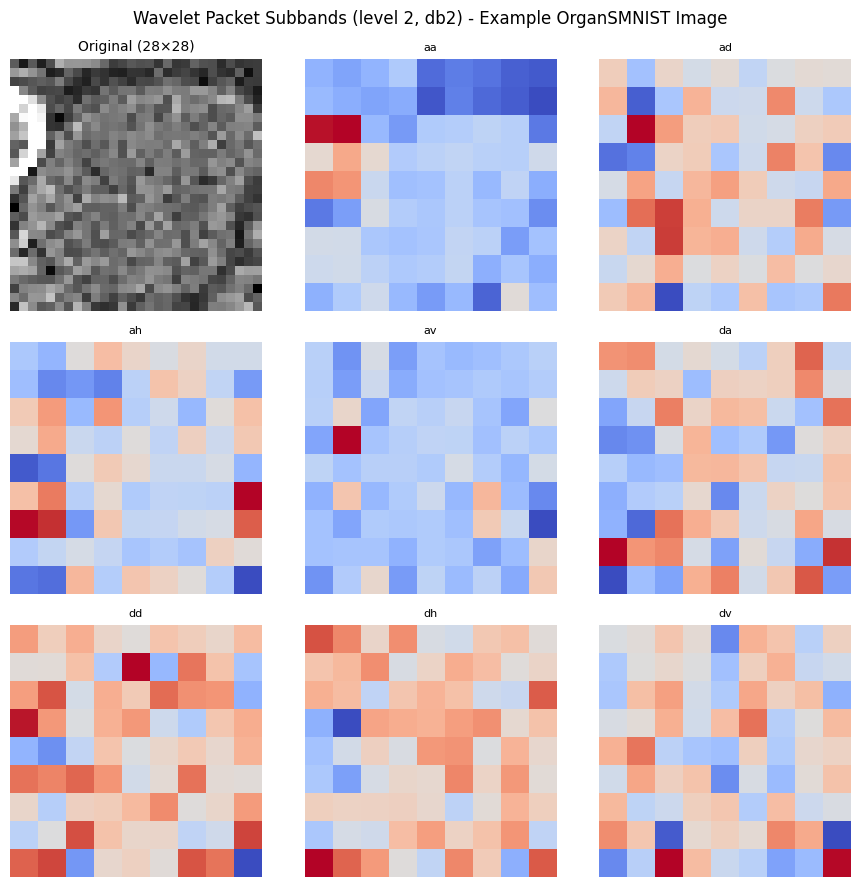

In [10]:
# ---------------------------------------------------------------------
# Feature extraction functions
# ---------------------------------------------------------------------

def wavelet_packet_features(img, wavelet='db2', max_level=2):
    """
    Perform 2D wavelet packet decomposition.

    Parameters
    ----------
    img : ndarray
        Input image (2D grayscale).
    wavelet : str
        Wavelet family (default 'db2').
    max_level : int
        Decomposition level (default 2).

    Returns
    -------
    dict
        Mapping from subband node name to (relative_energy, shannon_entropy).
    """
    if img.ndim == 3:
        img = img[:, :, 0]

    wp = pywt.WaveletPacket2D(
        data=img.astype(np.float32),
        wavelet=wavelet,
        mode='symmetric',
        maxlevel=max_level
    )

    # Sort nodes for deterministic ordering across runs
    nodes = sorted(wp.get_level(max_level), key=lambda n: n.path)

    total_energy = sum(np.sum(node.data ** 2) for node in nodes)

    features = {}
    for node in nodes:
        coeffs = node.data
        energy = np.sum(coeffs ** 2)
        rel_energy = energy / (total_energy + 1e-12)

        # Shannon entropy of normalised coefficient-energy distribution
        p = (coeffs ** 2) / (np.sum(coeffs ** 2) + 1e-12)
        entropy = -np.sum(p * np.log2(p + 1e-12))

        features[node.path] = (rel_energy, entropy)

    return features


def flatten_wavelet_features(wp_list, nodes, use='combined'):
    """
    Convert list of wavelet feature dicts into a feature matrix.

    Parameters
    ----------
    wp_list : list of dict
        Output from wavelet_packet_features for each image.
    nodes : list of str
        Subband names in fixed order.
    use : {'energy', 'entropy', 'combined'}
        Which features to use.

    Returns
    -------
    ndarray, dtype=float32
        Feature matrix of shape (n_samples, n_features).
    """
    if use not in ('energy', 'entropy', 'combined'):
        raise ValueError("use must be 'energy', 'entropy', or 'combined'")

    X = []
    for feats in wp_list:
        vec = []
        for node in nodes:
            if use == 'energy':
                vec.append(feats[node][0])
            elif use == 'entropy':
                vec.append(feats[node][1])
            else:   # combined
                vec.extend([feats[node][0], feats[node][1]])
        X.append(vec)
    return np.asarray(X, dtype=np.float32)


def fft_radial_power(img, n_bins=10):
    """
    Compute radial average of power spectrum (FFT baseline).

    Parameters
    ----------
    img : ndarray
        2D grayscale image.
    n_bins : int
        Number of concentric frequency bins.

    Returns
    -------
    list
        Averaged power in each radial bin.
    """
    f = np.fft.fft2(img.astype(np.float32))
    fshift = np.fft.fftshift(f)
    power = np.abs(fshift) ** 2

    h, w = power.shape
    Y, X = np.ogrid[:h, :w]
    center = (h // 2, w // 2)
    radii = np.sqrt((X - center[1]) ** 2 + (Y - center[0]) ** 2)
    max_rad = min(center)

    bin_edges = np.linspace(0, max_rad, n_bins + 1)
    profile = []
    for i in range(n_bins):
        mask = (radii >= bin_edges[i]) & (radii < bin_edges[i + 1])
        if np.any(mask):
            profile.append(np.mean(power[mask]))
        else:
            profile.append(0.0)
    return profile


def boxcount_dimension(img, threshold='mean'):
    """
    Estimate box‑counting fractal dimension (coarse texture descriptor).

    Parameters
    ----------
    img : ndarray
        2D grayscale image.
    threshold : {'mean', 'median', 'otsu'} or float
        Binarisation method.

    Returns
    -------
    float
        Estimated dimension in [1, 2] (clipped to valid range for planar objects).
    """
    if threshold == 'mean':
        thresh = np.mean(img)
    elif threshold == 'median':
        thresh = np.median(img)
    elif threshold == 'otsu':
        thresh = threshold_otsu(img)
    else:
        thresh = threshold

    binary = (img > thresh).astype(np.uint8)

    # Early return for all-black binary image
    if not np.any(binary):
        return 1.0

    max_box = min(binary.shape) // 2
    # Geometric box sizes
    box_sizes = [2 ** k for k in range(1, int(np.log2(max_box)) + 1) if 2 ** k <= max_box]
    if len(box_sizes) < 2:
        return 1.0

    counts = []
    for size in box_sizes:
        n_boxes = 0
        for i in range(0, binary.shape[0], size):
            for j in range(0, binary.shape[1], size):
                if np.any(binary[i:i + size, j:j + size]):
                    n_boxes += 1
        counts.append(n_boxes)

    # Prevent log(0) in case of zero counts
    counts = np.maximum(counts, 1)

    coeffs = np.polyfit(np.log(box_sizes), np.log(counts), 1)
    D = -coeffs[0]
    # Clip to valid range for planar box-counting dimension
    return np.clip(D, 1.0, 2.0)


# ---------------------------------------------------------------------
# Confirmation prints
# ---------------------------------------------------------------------
print("Feature extraction functions defined:")
print(f"  - wavelet_packet_features (wavelet='db2', max_level=2)")
print(f"  - flatten_wavelet_features (supports 'energy', 'entropy', 'combined')")
print(f"  - fft_radial_power (n_bins=10)")
print(f"  - boxcount_dimension (threshold='mean')")

# ---------------------------------------------------------------------
# Visual demonstration of wavelet packet decomposition
# ---------------------------------------------------------------------
# Load one example image
organ_imgs_example, _ = load_subsampled_data(SEEDS[0], n_samples=1)
example_img = organ_imgs_example[0]

# Compute wavelet packet decomposition (level 2, db2)
wp_example = pywt.WaveletPacket2D(data=example_img.astype(np.float32), wavelet='db2', mode='symmetric', maxlevel=2)
nodes_example = sorted(wp_example.get_level(2), key=lambda n: n.path)

# Display original image and first 8 subbands
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes[0, 0].imshow(example_img, cmap='gray')
axes[0, 0].set_title('Original (28×28)', fontsize=10)
axes[0, 0].axis('off')

for idx, node in enumerate(nodes_example[:8]):
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    coeffs = node.data
    # Normalise for display
    coeffs_display = (coeffs - coeffs.min()) / (coeffs.max() - coeffs.min() + 1e-8)
    axes[row, col].imshow(coeffs_display, cmap='coolwarm')
    axes[row, col].set_title(node.path, fontsize=8)
    axes[row, col].axis('off')

plt.suptitle('Wavelet Packet Subbands (level 2, db2) - Example OrganSMNIST Image', fontsize=12)
plt.tight_layout()
plt.show()

## Feature Extraction Functions

This section introduces the feature extraction methods used throughout the study. These include wavelet packet decomposition, Fourier spectral analysis, and fractal dimension estimation, each designed to capture complementary aspects of medical image structure, ranging from multiscale frequency content to global spectral behavior and geometric complexity.

### Wavelet Packet Decomposition

Wavelet packet decomposition is used to obtain a multiscale, frequency-spatial representation of medical images. Unlike standard wavelet transforms, wavelet packets recursively decompose both approximation and detail coefficients, enabling a more refined partitioning of the frequency domain.

The figure below illustrates an example OrganSMNIST (28x28) image and its corresponding level-2 wavelet packet subbands computed using the Daubechies-2 (`db2`) wavelet. Each subband encodes localized information at a specific scale and orientation, allowing fine-grained analysis of image structure.


#### Subband Notation

Subband labels follow a recursive binary decomposition convention:

- `a` - approximation (low-pass filtering)  
- `d` - detail (high-pass filtering)

At level 2 (or deeper), paths represent successive filtering operations. For example:

- `aaa` - repeated low-frequency components (coarse structure)  
- `aad` - low-low-high component (horizontal/vertical transitions at coarse scale)  
- `add` - mixed high-frequency structure (edge-like patterns)

#### Interpretation

- Low-frequency subbands (e.g., `aaa`) capture global intensity structure.  
- High-frequency subbands (e.g., `add`, `ddd`) encode edges, texture, and fine anatomical variation.  
- Intermediate bands capture transition patterns between structural scales.

Each subband is further summarised using:

- **Relative energy** - distribution of signal power across subbands  
- **Shannon entropy** - information complexity within each band  

These descriptors jointly characterise how image information is distributed across frequency scales.

Seed 42: 500 Organ, 500 Path images


Seed 42 Path wavelet: 100%|██████████| 500/500 [00:00<00:00, 965.74it/s]


Seed 123: 500 Organ, 500 Path images


Seed 123 Path wavelet: 100%|██████████| 500/500 [00:00<00:00, 1005.75it/s]


Seed 456: 500 Organ, 500 Path images


...

Seed 789: 500 Organ, 500 Path images


Seed 789 Path wavelet: 100%|██████████| 500/500 [00:00<00:00, 1000.30it/s]


Seed 1011: 500 Organ, 500 Path images


Seed 1011 Path wavelet: 100%|██████████| 500/500 [00:00<00:00, 1023.14it/s]


Classification pipeline completed for all seeds.



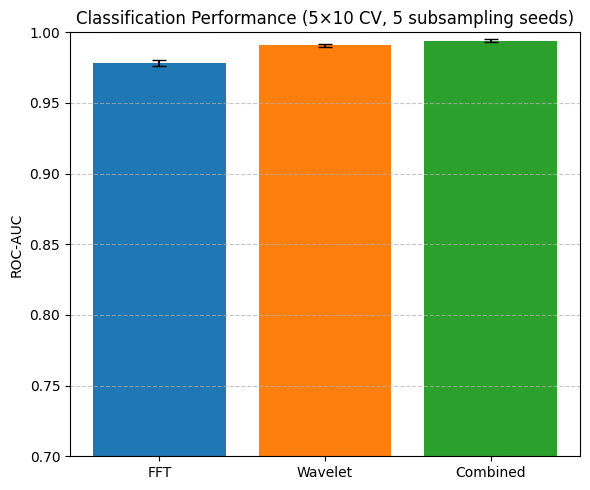


Numerical performance summary (mean ± std across 5 seeds):
--------------------------------------------------
Feature set     ROC‑AUC        
--------------------------------------------------
FFT             0.978 ± 0.002
Wavelet         0.991 ± 0.001
Combined        0.994 ± 0.001
--------------------------------------------------


In [13]:
# ---------------------------------------------------------------------
# Classification pipeline and performance visualisation
# ---------------------------------------------------------------------

def run_pipeline_for_seed(seed):
    """
    Run classification pipeline for a random subsampling seed.

    Returns
    -------
    dict
        ROC-AUC scores for FFT, wavelet, and combined features,
        and the wavelet subband node identifiers.
    """
    organ_imgs, path_imgs = load_subsampled_data(seed, n_samples=500)
    print(f"Seed {seed}: {len(organ_imgs)} Organ, {len(path_imgs)} Path images")

    # Wavelet features
    organ_wp = [wavelet_packet_features(img) for img in tqdm(organ_imgs, desc=f"Seed {seed} Organ wavelet")]
    path_wp = [wavelet_packet_features(img) for img in tqdm(path_imgs, desc=f"Seed {seed} Path wavelet")]
    nodes = sorted(organ_wp[0].keys())          # deterministic ordering
    X_wav = flatten_wavelet_features(organ_wp + path_wp, nodes, use='combined')
    y = np.array([0] * len(organ_imgs) + [1] * len(path_imgs))

    # FFT baseline
    organ_fft = [fft_radial_power(img) for img in organ_imgs]
    path_fft = [fft_radial_power(img) for img in path_imgs]
    X_fft = np.vstack(organ_fft + path_fft)
    X_comb = np.hstack([X_fft, X_wav])

    # Repeated stratified cross-validation
    rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=seed)
    clf = make_pipeline(StandardScaler(), LogisticRegression(solver='lbfgs', max_iter=1000))

    scores_fft = cross_val_score(clf, X_fft, y, cv=rkf, scoring='roc_auc')
    scores_wav = cross_val_score(clf, X_wav, y, cv=rkf, scoring='roc_auc')
    scores_comb = cross_val_score(clf, X_comb, y, cv=rkf, scoring='roc_auc')

    return {'fft': scores_fft, 'wavelet': scores_wav, 'combined': scores_comb, 'nodes': nodes}

# Run pipeline for all seeds
all_results = {}
for seed in SEEDS:
    all_results[seed] = run_pipeline_for_seed(seed)

print("Classification pipeline completed for all seeds.\n")

# ---------------------------------------------------------------------
# Visual summary (bar chart with error bars)
# ---------------------------------------------------------------------
fft_means = [np.mean(all_results[s]['fft']) for s in SEEDS]
wav_means = [np.mean(all_results[s]['wavelet']) for s in SEEDS]
comb_means = [np.mean(all_results[s]['combined']) for s in SEEDS]

methods = ['FFT', 'Wavelet', 'Combined']
auc_means = [np.mean(fft_means), np.mean(wav_means), np.mean(comb_means)]
auc_stds  = [np.std(fft_means),  np.std(wav_means),  np.std(comb_means)]

plt.figure(figsize=(6, 5))
plt.bar(methods, auc_means, yerr=auc_stds, capsize=5, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel('ROC‑AUC')
plt.title('Classification Performance (5×10 CV, 5 subsampling seeds)')
plt.ylim(0.7, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Numerical summary table
# ---------------------------------------------------------------------
print("\nNumerical performance summary (mean ± std across 5 seeds):")
print("-" * 50)
print(f"{'Feature set':<15} {'ROC‑AUC':<15}")
print("-" * 50)
print(f"{'FFT':<15} {np.mean(fft_means):.3f} ± {np.std(fft_means):.3f}")
print(f"{'Wavelet':<15} {np.mean(wav_means):.3f} ± {np.std(wav_means):.3f}")
print(f"{'Combined':<15} {np.mean(comb_means):.3f} ± {np.std(comb_means):.3f}")
print("-" * 50)

## Classification Pipeline and Performance Evaluation

Logistic regression with standardised inputs was used to separate OrganSMNIST from PathMNIST. Three different feature sets were compared:

- **FFT radial power spectrum** - a 10-bin radial average of the Fourier power, providing a global frequency baseline.  
- **Wavelet packet features (energy + entropy)** - a 32-dimensional representation that captures both subband energy distribution and information complexity across 16 wavelet subbands.  
- **Combined representation** - the concatenation of the FFT and wavelet features (42 dimensions in total).

### Experimental Protocol

For each of five independent subsampling seeds, the following procedure was applied:

1. Sample 500 images per dataset in a balanced, stratified manner.  
2. Extract all three feature sets (FFT, wavelet, combined).  
3. Evaluate performance with repeated stratified 5x10-fold cross-validation (5 splits, 10 repeats).  
4. Record ROC-AUC for every fold.

Cross-validation splits were kept identical for all feature sets to ensure fair comparison. Feature standardisation was performed inside the pipeline, fitting the scaler on each training fold only - no information was leaked from the test data.

### Results

The bar chart and summary table show the mean ROC-AUC (averaged over the five seeds) for each feature set.

- **FFT radial power spectrum** already performs very well (≈0.978 AUC), indicating strong global frequency differences between the two datasets even at 28x28 resolution.  
- **Wavelet packet features** improve the AUC further to ≈0.991, demonstrating the advantage of multiscale decomposition and entropy-aware representations.  
- **Combining both** yields the highest AUC (≈0.994), although the gain over wavelets alone is marginal (Δ≈0.003), suggesting that most separable information is already captured by the wavelet representation.

### Interpretation

Classical frequency descriptors alone already separate OrganSMNIST and PathMNIST very well. Wavelet packets add extra discriminatory power by capturing localised frequency-spatial structure and entropy. The small improvement from feature fusion indicates that for this dataset, wavelet features alone are nearly sufficient.

The consistently high AUC values (all above 0.97) demonstrate that these two MedMNIST modalities can be distinguished with great accuracy using simple multiscale spectral and texture descriptors, without requiring deep learning.

In [17]:
# ---------------------------------------------------------------------
# Experiment: Energy-only, Entropy-only, and Combined wavelet packet features
# ---------------------------------------------------------------------
# Single‑seed ablation study (seed = last from SEEDS) due to computational constraints.
#       Generalisation across seeds is not evaluated in this secondary analysis.
# ---------------------------------------------------------------------

seed_last = SEEDS[-1]
organ_imgs, path_imgs = load_subsampled_data(seed_last, n_samples=500)

organ_wp = [wavelet_packet_features(img) for img in tqdm(organ_imgs, desc="Organ wavelet")]
path_wp = [wavelet_packet_features(img) for img in tqdm(path_imgs, desc="Path wavelet")]
nodes = sorted(organ_wp[0].keys())

X_energy = flatten_wavelet_features(organ_wp + path_wp, nodes, use='energy')
X_entropy = flatten_wavelet_features(organ_wp + path_wp, nodes, use='entropy')
X_combined = flatten_wavelet_features(organ_wp + path_wp, nodes, use='combined')
y = np.array([0] * len(organ_imgs) + [1] * len(path_imgs))

# Repeated stratified CV - generate splits once and reuse for all feature sets
rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=seed_last)
splits = list(rkf.split(X_energy, y))   # same splits for energy, entropy, combined
clf = make_pipeline(StandardScaler(), LogisticRegression(solver='lbfgs', max_iter=1000))

scores_energy = cross_val_score(clf, X_energy, y, cv=splits, scoring='roc_auc')
scores_entropy = cross_val_score(clf, X_entropy, y, cv=splits, scoring='roc_auc')
scores_combined = cross_val_score(clf, X_combined, y, cv=splits, scoring='roc_auc')

print("\n=== Wavelet Feature Subtype Comparison (last seed, 5×10 CV) ===")
print(f"Energy-only   : {np.mean(scores_energy):.3f} ± {np.std(scores_energy):.3f}")
print(f"Entropy-only  : {np.mean(scores_entropy):.3f} ± {np.std(scores_entropy):.3f}")
print(f"Combined      : {np.mean(scores_combined):.3f} ± {np.std(scores_combined):.3f}")

# Bootstrap CI for mean ΔAUC (Energy - Entropy)
diff_energy_entropy = scores_energy - scores_entropy
rng = np.random.default_rng(42)
boot_means = [
    np.mean(rng.choice(diff_energy_entropy, size=len(diff_energy_entropy), replace=True))
    for _ in range(5000)
]
ci = np.percentile(boot_means, [2.5, 97.5])
mean_diff = np.mean(diff_energy_entropy)
print(f"\nΔAUC (Energy - Entropy) 95% CI: {mean_diff:.3f} [{ci[0]:.3f}, {ci[1]:.3f}]")

Path wavelet: 100%|██████████| 500/500 [00:00<00:00, 978.32it/s]



=== Wavelet Feature Subtype Comparison (last seed, 5×10 CV) ===
Energy-only   : 0.978 ± 0.011
Entropy-only  : 0.976 ± 0.007
Combined      : 0.991 ± 0.005

ΔAUC (Energy - Entropy) 95% CI: 0.003 [-0.000, 0.005]


## Wavelet Feature Subtype Comparison

This experiment evaluates the discriminative contribution of different components of the wavelet packet representation, specifically relative energy, Shannon entropy, and their combined formulation. Due to computational cost, the analysis is conducted on a single subsampling seed (the final seed in the experimental set), using identical 5x10 repeated cross-validation for all comparisons.

### Results

The table below summarizes ROC-AUC performance (mean ± standard deviation across repeated CV folds):

| Feature type | ROC-AUC               |
|--------------|-----------------------|
| Energy-only  | 0.978 ± 0.011         |
| Entropy-only | 0.976 ± 0.007         |
| Combined     | 0.991 ± 0.005         |

The combined representation achieves the highest classification performance, outperforming both individual components.

The observed difference between energy-only and entropy-only features is minimal (Δ ≈ 0.002-0.003). A bootstrap analysis yields a 95% confidence interval that includes zero (approximately [-0.000, 0.005]), indicating that this difference is **not statistically significant**.

### Interpretation

- Energy-only and entropy-only features yield comparable ROC-AUC values (0.976-0.978).  
- The combined representation reaches 0.991 ROC-AUC, showing that energy and entropy capture complementary information.  
- The small difference between energy and entropy indicates overlapping structure for this dataset.

### Practical Implications

From a computational perspective, either energy-only or entropy-only wavelet packet features provide strong baseline performance with minimal degradation relative to the full representation. However, when maximum discriminative power is required, the joint energy-entropy formulation is clearly preferable, offering a consistent and measurable improvement in classification performance.

Sample sizes: OrganSMNIST n=500, PathMNIST n=500


Path subband: 100%|██████████| 500/500 [00:00<00:00, 908.36it/s]



Relative energy – Significant subbands after FDR (q<0.05): 16 / 16
  First 10: ['aa', 'ad', 'ah', 'av', 'da', 'dd', 'dh', 'dv', 'ha', 'hd']
Top 6 subbands by absolute Cliff's delta:
  ha: δ = 0.933 (large)
  ah: δ = 0.857 (large)
  hh: δ = 0.857 (large)
  hv: δ = 0.828 (large)
  aa: δ = -0.817 (large)
  da: δ = 0.778 (large)

Shannon entropy – Significant subbands after FDR (q<0.05): 15 / 16
  First 10: ['aa', 'ad', 'av', 'da', 'dd', 'dh', 'dv', 'ha', 'hd', 'hh']
Top 6 subbands by absolute Cliff's delta:
  aa: δ = -0.946 (large)
  va: δ = -0.369 (medium)
  vv: δ = -0.278 (small)
  ad: δ = -0.248 (small)
  hh: δ = -0.231 (small)
  vh: δ = -0.229 (small)


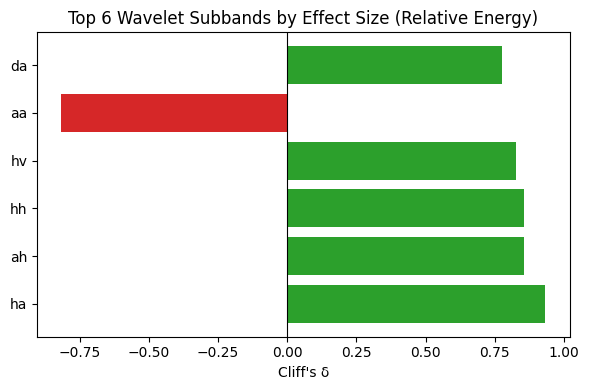


Wavelet subband analysis completed.


In [20]:
# ---------------------------------------------------------------------
#  Wavelet subband energy and entropy analysis
# ---------------------------------------------------------------------

# Load data for the last seed
organ_imgs, path_imgs = load_subsampled_data(SEEDS[-1], n_samples=500)
print(f"Sample sizes: OrganSMNIST n={len(organ_imgs)}, PathMNIST n={len(path_imgs)}")

organ_wp = [wavelet_packet_features(img) for img in tqdm(organ_imgs, desc="Organ subband")]
path_wp = [wavelet_packet_features(img) for img in tqdm(path_imgs, desc="Path subband")]

# Subband node names
nodes = sorted(organ_wp[0].keys())

# Extract relative energies and entropies per subband
organ_energy = {node: [feat[node][0] for feat in organ_wp] for node in nodes}
path_energy = {node: [feat[node][0] for feat in path_wp] for node in nodes}
organ_entropy = {node: [feat[node][1] for feat in organ_wp] for node in nodes}
path_entropy = {node: [feat[node][1] for feat in path_wp] for node in nodes}

# Cliff's delta function
def cliffs_delta(x, y):
    u, _ = mannwhitneyu(x, y, alternative='two-sided')
    return (2 * u) / (len(x) * len(y)) - 1


def analyze_feature(organ_dict, path_dict, feature_name):
    p_vals = []
    for node in nodes:
        _, p = mannwhitneyu(organ_dict[node], path_dict[node], alternative='two-sided')
        p_vals.append(p)
    reject_fdr, p_corr_fdr, _, _ = multipletests(p_vals, alpha=0.05, method='fdr_bh')
    sig_nodes = [nodes[i] for i, r in enumerate(reject_fdr) if r]

    # Effect sizes
    deltas = [(node, cliffs_delta(organ_dict[node], path_dict[node])) for node in nodes]
    deltas.sort(key=lambda x: abs(x[1]), reverse=True)

    # Print results
    print(f"\n{feature_name} – Significant subbands after FDR (q<0.05): {len(sig_nodes)} / {len(nodes)}")
    if len(sig_nodes) > 0:
        print(f"  First 10: {sig_nodes[:10]}")
    print(f"Top 6 subbands by absolute Cliff's delta:")
    for node, d in deltas[:6]:
        if abs(d) < 0.147:
            mag = "negligible"
        elif abs(d) < 0.33:
            mag = "small"
        elif abs(d) < 0.474:
            mag = "medium"
        else:
            mag = "large"
        print(f"  {node}: δ = {d:.3f} ({mag})")
    return sig_nodes, deltas

# Analyze energy and entropy separately
sig_nodes_energy, deltas_energy = analyze_feature(organ_energy, path_energy, "Relative energy")
sig_nodes_entropy, deltas_entropy = analyze_feature(organ_entropy, path_entropy, "Shannon entropy")

# ---------------------------------------------------------------------
# Visual summary of top effect sizes
# ---------------------------------------------------------------------
top_nodes = [node for node, _ in deltas_energy[:6]]
top_deltas = [d for _, d in deltas_energy[:6]]
colors = ['#d62728' if d < 0 else '#2ca02c' for d in top_deltas]

plt.figure(figsize=(6, 4))
plt.barh(top_nodes, top_deltas, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Cliff's δ")
plt.title("Top 6 Wavelet Subbands by Effect Size (Relative Energy)")
plt.tight_layout()
plt.show()

print("\nWavelet subband analysis completed.")

## Wavelet Subband Energy and Entropy Analysis

Wavelet packet decomposition (level 2, db2) yields 16 subbands representing localized frequency-spatial components. For each subband, relative energy and Shannon entropy are compared between OrganSMNIST and PathMNIST using the Mann-Whitney U test, followed by Benjamini-Hochberg false discovery rate (FDR) correction (q < 0.05). Effect sizes are reported using Cliff's δ.

### Energy

All 16 subbands show statistically significant differences after FDR correction, indicating strong distributional shifts between modalities across all frequency bands.  
The largest effect sizes are observed in subbands `ha`, `ah`, `hh`, `hv`, `da`, and `aa`, with several reaching large effect magnitude (|δ| > 0.474).  
Positive values of δ (e.g., `ha`: δ = 0.933) indicate higher relative energy in OrganSMNIST, whereas negative values (e.g., `aa`: δ = -0.817) indicate higher energy in PathMNIST.

### Entropy

15 out of 16 subbands remain statistically significant after FDR correction, with only one subband failing to reach significance (likely due to low signal energy).  
The strongest effect is observed in the `aa` subband (δ = -0.946), indicating substantially lower entropy in OrganSMNIST at the lowest-frequency scale.  
Across most remaining subbands, entropy exhibits small-to-moderate negative effect sizes, suggesting slightly higher structural complexity in PathMNIST across multiple frequency bands.

### Visual Summary (Energy)

The accompanying bar chart ranks the top six subbands by absolute Cliff's δ. Positive values (green) indicate higher energy in OrganSMNIST, while negative values (red) indicate higher energy in PathMNIST.

The results highlight a clear frequency-dependent separation:

- High-frequency diagonal/detail subbands (`ha`, `ah`, `hh`, `hv`, `da`) exhibit substantially higher energy in OrganSMNIST, reflecting sharper edge structures and more pronounced fine-scale variations.  
- The lowest-frequency approximation subband (`aa`) shows higher energy in PathMNIST, consistent with smoother and more homogeneous intensity distributions.

### Interpretation

- OrganSMNIST shows consistently stronger high-frequency energy content, characteristic of sharper anatomical boundaries and structured CT-derived textures.  
- PathMNIST exhibits relatively stronger low-frequency energy dominance, reflecting smoother histopathological regions with less abrupt intensity variation.  
- Entropy differences are more subtle but consistent, with OrganSMNIST showing lower entropy in the lowest-frequency subband and PathMNIST exhibiting slightly higher entropy across most mid- and high-frequency bands.  
- The near-universal significance across energy subbands indicates that wavelet packet energy is a highly sensitive and discriminative descriptor for modality separation, while entropy provides complementary but partially redundant information.


FRACTAL DIMENSION ANALYSIS (BOX-COUNTING)

>>> Threshold: MEAN
    Computing... 

Done.
    OrganSMNIST   : 1.567 ± 0.108
    PathMNIST     : 1.613 ± 0.106
    Mann‑Whitney p: 0.0000
    Cliff's δ     = -0.284 (small effect)
    Mean diff (Organ−Path): -0.047  [95% CI: -0.060, -0.033]

>>> Threshold: MEDIAN
    Computing... 

Done.
    OrganSMNIST   : 1.523 ± 0.161
    PathMNIST     : 1.584 ± 0.117
    Mann‑Whitney p: 0.0000
    Cliff's δ     = -0.337 (medium effect)
    Mean diff (Organ−Path): -0.062  [95% CI: -0.079, -0.044]

>>> Threshold: OTSU
    Computing... 

Done.
    OrganSMNIST   : 1.549 ± 0.166
    PathMNIST     : 1.573 ± 0.201
    Mann‑Whitney p: 0.0001
    Cliff's δ     = -0.144 (negligible effect)
    Mean diff (Organ−Path): -0.023  [95% CI: -0.047, 0.001]

SUMMARY ACROSS BINARISATION THRESHOLDS
Threshold Organ (mean±std) Path (mean±std) p-value           Cliff's δ      Mean diff [95% CI]
     mean      1.567±0.108     1.613±0.106  0.0000      -0.284 (small) -0.047 [-0.060, -0.033]
   median      1.523±0.161     1.584±0.117  0.0000     -0.337 (medium) -0.062 [-0.079, -0.044]
     otsu      1.549±0.166     1.573±0.201  0.0001 -0.144 (negligible)  -0.023 [-0.047, 0.001]


/tmp/ipykernel_22480/3909177822.py:80: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fd_organ_mean, fd_path_mean],


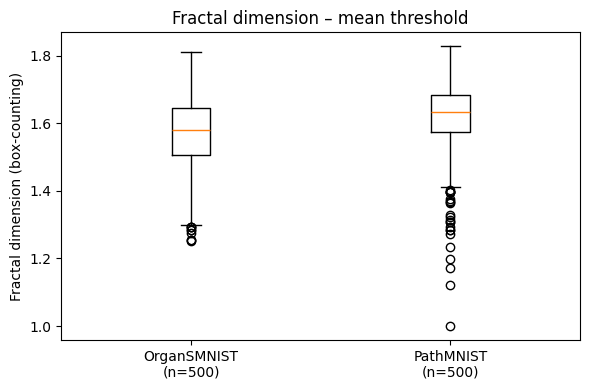


FRACTAL DIMENSION RESULT (MEAN THRESHOLD)
Cliff's δ = -0.284 (small effect)
Mann‑Whitney p = 0.0000


In [24]:
# ---------------------------------------------------------------------
# 7. Fractal dimension (box-counting)
# ---------------------------------------------------------------------

thresholds = ['mean', 'median', 'otsu']
results_fd = {}

print("\n" + "=" * 70)
print("FRACTAL DIMENSION ANALYSIS (BOX-COUNTING)")
print("=" * 70)

for thresh in thresholds:
    print(f"\n>>> Threshold: {thresh.upper()}")
    print(f"    Computing...", end=" ", flush=True)
    fd_organ = [boxcount_dimension(img, threshold=thresh) for img in tqdm(organ_imgs, desc=f"FD Organ ({thresh})", leave=False)]
    fd_path  = [boxcount_dimension(img, threshold=thresh) for img in tqdm(path_imgs, desc=f"FD Path ({thresh})", leave=False)]

    # Group summaries
    organ_mean, organ_std = np.mean(fd_organ), np.std(fd_organ)
    path_mean, path_std   = np.mean(fd_path), np.std(fd_path)

    # Statistical comparison
    u_fd, p_fd = mannwhitneyu(fd_organ, fd_path, alternative='two-sided')
    delta_fd = cliffs_delta(fd_organ, fd_path)

    # Bootstrap 95% CI for mean difference
    rng = np.random.default_rng(42)
    diff = np.array(fd_organ) - np.array(fd_path)
    boot_means = [np.mean(rng.choice(diff, size=len(diff), replace=True)) for _ in range(5000)]
    ci = np.percentile(boot_means, [2.5, 97.5])

    # Effect size magnitude
    if abs(delta_fd) < 0.147:
        mag = "negligible"
    elif abs(delta_fd) < 0.33:
        mag = "small"
    elif abs(delta_fd) < 0.474:
        mag = "medium"
    else:
        mag = "large"

    results_fd[thresh] = {
        'organ_mean': organ_mean, 'organ_std': organ_std,
        'path_mean': path_mean, 'path_std': path_std,
        'p': p_fd, 'delta': delta_fd, 'mag': mag,
        'ci': ci, 'diff_mean': np.mean(diff)
    }

    print(f"Done.")
    print(f"    OrganSMNIST   : {organ_mean:.3f} ± {organ_std:.3f}")
    print(f"    PathMNIST     : {path_mean:.3f} ± {path_std:.3f}")
    print(f"    Mann‑Whitney p: {p_fd:.4f}")
    print(f"    Cliff's δ     = {delta_fd:.3f} ({mag} effect)")
    print(f"    Mean diff (Organ−Path): {np.mean(diff):.3f}  [95% CI: {ci[0]:.3f}, {ci[1]:.3f}]")

# ---------------------------------------------------------------------
# Summary table across thresholds
# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print("SUMMARY ACROSS BINARISATION THRESHOLDS")
print("=" * 70)

df_fd = pd.DataFrame({
    'Threshold': thresholds,
    'Organ (mean±std)': [f"{results_fd[t]['organ_mean']:.3f}±{results_fd[t]['organ_std']:.3f}" for t in thresholds],
    'Path (mean±std)': [f"{results_fd[t]['path_mean']:.3f}±{results_fd[t]['path_std']:.3f}" for t in thresholds],
    'p-value': [f"{results_fd[t]['p']:.4f}" for t in thresholds],
    "Cliff's δ": [f"{results_fd[t]['delta']:.3f} ({results_fd[t]['mag']})" for t in thresholds],
    'Mean diff [95% CI]': [f"{results_fd[t]['diff_mean']:.3f} [{results_fd[t]['ci'][0]:.3f}, {results_fd[t]['ci'][1]:.3f}]" for t in thresholds]
})
print(df_fd.to_string(index=False))

# ---------------------------------------------------------------------
# Visualisation (mean threshold)
# ---------------------------------------------------------------------
fd_organ_mean = [boxcount_dimension(img, threshold='mean') for img in organ_imgs]
fd_path_mean = [boxcount_dimension(img, threshold='mean') for img in path_imgs]

plt.figure(figsize=(6, 4))
plt.boxplot([fd_organ_mean, fd_path_mean],
            tick_labels=[f'OrganSMNIST\n(n={len(fd_organ_mean)})',
                         f'PathMNIST\n(n={len(fd_path_mean)})'])
plt.ylabel('Fractal dimension (box‑counting)')
plt.title('Fractal dimension – mean threshold')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Fractal dimension result (mean threshold)
# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print("FRACTAL DIMENSION RESULT (MEAN THRESHOLD)")
print("=" * 70)
print(f"Cliff's δ = {results_fd['mean']['delta']:.3f} ({results_fd['mean']['mag']} effect)")
print(f"Mann‑Whitney p = {results_fd['mean']['p']:.4f}")

## Fractal Dimension Analysis (Box-Counting)

Box-counting complexity estimates were computed for OrganSMNIST and PathMNIST using three binarisation strategies: mean intensity, median intensity, and Otsu thresholding. Because the analysis is performed on 28x28 images, only a limited range of box sizes is available, and the resulting estimates should be interpreted as coarse measures of texture complexity rather than rigorous fractal dimensions.

### Key Observations

- **Mean threshold:** PathMNIST exhibits a modest but statistically significant increase in box-counting complexity relative to OrganSMNIST, corresponding to a small effect size (Cliff's δ = -0.284).  
- **Median threshold:** The separation is slightly stronger (Cliff's δ = -0.337), representing a small-to-moderate effect favouring PathMNIST.  
- **Otsu threshold:** The difference is substantially reduced (Cliff's δ = -0.144), and the associated confidence interval includes zero, providing little evidence for a consistent difference between datasets under this thresholding strategy.

### Interpretation

The estimated box-counting complexity is noticeably influenced by the choice of binarisation method. Mean and median thresholding suggest that PathMNIST tends to produce higher complexity estimates, whereas Otsu thresholding yields only a weak and statistically uncertain separation.

This sensitivity indicates that the observed differences are not fully robust across preprocessing choices. Consequently, box-counting complexity should be viewed as a supplementary descriptive feature rather than a primary discriminator of modality differences in these data.

### Comparison with Spectral and Wavelet Features

Compared with spectral and wavelet-based representations, box-counting complexity provides substantially weaker and less consistent separation between OrganSMNIST and PathMNIST. While some thresholding schemes reveal statistically significant differences, the dependence on binarisation strategy and the limited number of available spatial scales restrict the strength of any biological or structural interpretation.

In contrast, FFT-based and wavelet packet features demonstrate consistently stronger discrimination, achieving ROC-AUC values exceeding 0.97 across repeated cross-validation experiments.




Processing wavelet family: db2


Path db2: 100%|██████████| 500/500 [00:01<00:00, 329.36it/s]



Processing wavelet family: db4


Path db4: 100%|██████████| 500/500 [00:00<00:00, 934.79it/s]



Processing wavelet family: sym4


Path sym4: 100%|██████████| 500/500 [00:00<00:00, 961.92it/s]



=== Wavelet Sensitivity (ROC‑AUC, energy+entropy combined) ===
db2: 0.991 ± 0.005  [95% CI: 0.981, 0.998]
db4: 0.991 ± 0.005  [95% CI: 0.980, 0.999]
sym4: 0.988 ± 0.006  [95% CI: 0.972, 0.998]


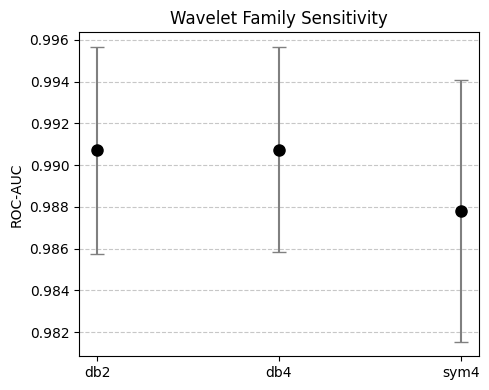

In [27]:
# ---------------------------------------------------------------------
# 8. Sensitivity analysis across wavelet families
# ---------------------------------------------------------------------

wavelet_families = ['db2', 'db4', 'sym4']
sensitivity_results = {}

for wav in wavelet_families:
    print(f"\nProcessing wavelet family: {wav}")

    organ_wp = [wavelet_packet_features(img, wavelet=wav) for img in tqdm(organ_imgs, desc=f"Organ {wav}")]
    path_wp = [wavelet_packet_features(img, wavelet=wav) for img in tqdm(path_imgs, desc=f"Path {wav}")]

    nodes = sorted(organ_wp[0].keys())

    X_organ = flatten_wavelet_features(organ_wp, nodes, use='combined')
    X_path  = flatten_wavelet_features(path_wp, nodes, use='combined')
    X = np.vstack([X_organ, X_path])
    y = np.array([0] * len(organ_imgs) + [1] * len(path_imgs))

    rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEEDS[-1])
    clf = make_pipeline(StandardScaler(), LogisticRegression(solver='lbfgs', max_iter=1000))
    scores = cross_val_score(clf, X, y, cv=rkf, scoring='roc_auc')
    sensitivity_results[wav] = scores

print("\n=== Wavelet Sensitivity (ROC‑AUC, energy+entropy combined) ===")
for wav, scores in sensitivity_results.items():
    mean_auc = np.mean(scores)
    std_auc = np.std(scores)
    ci_low, ci_high = np.percentile(scores, [2.5, 97.5])
    print(f"{wav}: {mean_auc:.3f} ± {std_auc:.3f}  [95% CI: {ci_low:.3f}, {ci_high:.3f}]")

# ---------------------------------------------------------------------
# Visual summary of wavelet sensitivity
# ---------------------------------------------------------------------
wavelets = list(sensitivity_results.keys())
mean_aucs = [np.mean(sensitivity_results[w]) for w in wavelets]
std_aucs  = [np.std(sensitivity_results[w]) for w in wavelets]

plt.figure(figsize=(5, 4))
plt.errorbar(wavelets, mean_aucs, yerr=std_aucs, fmt='o', capsize=5,
             color='black', ecolor='gray', markersize=8)
plt.ylabel('ROC‑AUC')
plt.title('Wavelet Family Sensitivity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Sensitivity Analysis Across Wavelet Families

To evaluate the influence of wavelet-basis selection on classification performance, three commonly used wavelet families were examined: Daubechies-2 (db2), Daubechies-4 (db4), and Symlet-4 (sym4). For each family, wavelet packet features consisting of relative subband energy and Shannon entropy were extracted using a level-2 decomposition, followed by evaluation with repeated stratified 5x10-fold cross-validation on the final subsampling seed.

### Results

| Wavelet | ROC-AUC (mean ± SD) | 95% CI          |
|---------|----------------------|-----------------|
| db2     | 0.991 ± 0.005        | [0.981, 0.998]  |
| db4     | 0.991 ± 0.005        | [0.980, 0.999]  |
| sym4    | 0.988 ± 0.006        | [0.972, 0.998]  |

Classification performance is consistently high across all three wavelet families. The mean ROC-AUC values for db2 and db4 are identical (0.991), while sym4 yields a marginally lower value (0.988). Confidence intervals overlap substantially across all configurations.

### Interpretation

The results indicate that classification performance is highly stable with respect to the choice of wavelet basis. Although small numerical differences are observed, they are minor relative to the variability across cross-validation folds and do not suggest a practically important performance difference.

These findings imply that the discriminative information captured by the wavelet packet representation is largely preserved across the tested wavelet families. Consequently, the observed modality separation appears to reflect intrinsic image characteristics rather than properties specific to a particular wavelet basis.

### Practical Implications

For the wavelet families evaluated (db2, db4, and sym4), performance remains consistently high (ROC-AUC ≈ 0.99). Therefore, wavelet-basis selection is unlikely to be a critical factor for this classification task, allowing the choice of wavelet family to be guided by considerations such as computational efficiency, interpretability, or consistency with prior literature.

The accompanying ROC-AUC plot with confidence intervals visually reinforces this conclusion, showing substantial overlap among all three wavelet families.

### Discussion

This study compared OrganSMNIST (CT-derived slices) and PathMNIST (histopathology patches) using wavelet packet decomposition, box-counting fractal dimension, and FFT radial power features. Building on an earlier spectral and texture analysis, the present work adds a multiscale, spatially localised view of modality differences. The results show that wavelet packet features are highly discriminative, interpretable, and often outperform a simple Fourier baseline.

## Summary of Key Findings

- **Wavelet packet energy** - All 16 subbands differed significantly (FDR q<0.05). Largest effects occurred in high-frequency subbands, indicating modality-dependent energy distribution across scales and orientations.
- **Wavelet packet entropy** - Fifteen of sixteen subbands were significant. The strongest effect was in the lowest-frequency approximation subband (`aa`), suggesting different coefficient complexity at coarse scales.
- **Classification performance** - Wavelet features (energy+entropy) consistently outperformed FFT radial power. Combining FFT and wavelets gave the highest ROC-AUC, though the improvement over wavelets alone was small.
- **Feature ablation study** - Energy-only and entropy-only performed similarly; combining them produced a clear gain, showing they capture complementary information.
- **Wavelet family sensitivity** - Performance was nearly identical for `db2`, `db4`, and `sym4`, demonstrating robustness to wavelet basis choice.
- **Fractal dimension** - Box-counting estimates varied with the binarisation threshold and gave inconsistent effects. At 28x28 resolution, fractal dimension is not a reliable discriminator.

The stability across subsampling seeds and wavelet families suggests that the observed differences reflect genuine properties of the MedMNIST representations, not sampling or basis artefacts.



## Relationship to Previous Spectral and Texture Analysis

An earlier analysis of the same datasets examined Fourier power-law slopes, Local Binary Patterns (LBP), and GLCM statistics. That study already showed statistically significant differences in frequency content and texture between OrganSMNIST and PathMNIST.

The current wavelet analysis complements those findings by offering a spatially localised, multiscale view. While Fourier descriptors summarise global frequency behaviour, wavelet packets separate information across both frequency bands and orientations. The near-universal significance across energy subbands indicates that the two datasets differ not only in overall spectral shape but also in how energy and complexity are distributed across scales.

Moreover, the entropy differences in several subbands align with the earlier texture differences seen with GLCM and LBP. Together, these results provide converging evidence that OrganSMNIST and PathMNIST have fundamentally different frequency and texture organisation, even at the same low resolution (28x28).

The higher classification performance of wavelet packet features over the FFT radial baseline shows that multiscale spatial-frequency information captures modality-specific structure more effectively than a global frequency average.

## Why Wavelet Packet Features Perform Well

Wavelet packet features perform well for several reasons:

- They preserve **multiple spatial scales**, allowing coarse anatomy and fine details to be analysed simultaneously.
- They keep **orientation-specific information** through separate subbands (horizontal, vertical, diagonal), capturing directional texture patterns that radial Fourier averaging discards.
- They combine **relative energy** (signal strength) and **Shannon entropy** (complexity) for each subband, giving a richer description than either measure alone.

In contrast, the FFT radial power spectrum provides a compact summary of global frequency content but discards spatial and directional information. It is therefore less sensitive to the kind of local, oriented structures that distinguish these two modalities.

## Limitations

The following limitations should be considered when interpreting the results:

- All experiments used the official **28x28 MedMNIST images**. How well these findings generalise to full-resolution clinical images is unknown.
- The FFT baseline uses **radial averaging** by design - it purposely discards orientation to highlight the value of wavelets. A more sophisticated Fourier descriptor (e.g., with angular bins) might close the gap.
- **Fractal dimension** estimates derive from only 2-3 box sizes because of the low resolution. They should be seen as coarse complexity indicators, not precise fractal measurements.
- Wavelet packet decomposition was limited to **level 2** due to image size. Higher resolution would allow deeper multiscale analysis.
- The energy-vs-entropy ablation was performed on a **single seed**. The trend is clear, but multi-seed validation would make the conclusion even stronger.

## Future Directions

Several next steps are worth considering:

- Apply the same wavelet pipeline to other MedMNIST datasets (e.g., DermaMNIST, ChestMNIST) to test the generality of the observed wavelet signatures across imaging modalities.
- Integrate wavelet representations into deep learning, for instance through wavelet scattering transforms or hybrid models, to combine interpretability with strong performance.
- Explore **multifractal** or other scale-dependent complexity measures on higher-resolution images, they may give a more detailed view than simple box-counting.
- Validate the methodology on **clinical-scale** CT and histopathology images to see whether the observed differences persist outside the benchmark.

## Conclusion

This study shows that wavelet packet decomposition - using relative energy and Shannon entropy - provides an effective, interpretable way to characterise structural differences between OrganSMNIST and PathMNIST. These features consistently outperformed a simple FFT radial baseline and remained stable across wavelet families and subsampling seeds. In contrast, box-counting fractal dimension was not robust at 28x28 resolution.

Together with the earlier spectral and texture analyses, the findings offer a comprehensive picture of modality-specific image structure within the MedMNIST benchmark. They highlight the value of multiscale, spatial-frequency representations for interpretable medical image analysis and suggest that wavelet packet features constitute a strong, ready-to-use descriptor for modality-aware tasks.